Load model and dataset

In [50]:
import joblib
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

model = joblib.load("../models/lightgbm_dynamic_pricing.pkl")
test_dataset = pd.read_csv("../datasets/test_dataset.csv")

Inspect test dataset datatypes

In [51]:
test_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   property_id                 50000 non-null  str    
 1   Unnamed: 1                  50000 non-null  int64  
 2   date                        50000 non-null  str    
 3   location_score              50000 non-null  int64  
 4   amenities_score             50000 non-null  int64  
 5   rating                      50000 non-null  float64
 6   base_price                  50000 non-null  float64
 7   month                       50000 non-null  int64  
 8   weekend                     50000 non-null  int64  
 9   holiday                     50000 non-null  int64  
 10  demand                      50000 non-null  float64
 11  competitor_price            50000 non-null  float64
 12  nearby_event                50000 non-null  int64  
 13  market_trend                50000 non-null

Remove NA values

In [52]:
test_dataset['date'] = pd.to_datetime(test_dataset['date'])

test_valid_idx = test_dataset.dropna().index
test_dataset = test_dataset.loc[test_valid_idx]

Remove unwanted columns and rename any if required

In [53]:
X_test = test_dataset.drop(
  columns=[
    'Unnamed: 1',
    'revenue',
    'occupancy_rate',
    'property_id',
    'date'
  ]
)
y_test = test_dataset['occupancy_rate']

X_test.columns = (
    X_test.columns
    .str.replace(' ', '_')
    .str.replace(r'[^A-Za-z0-9_]', '', regex=True)
)

Perform predictions on the test dataset

In [54]:
y_pred = np.array(model.predict(X_test))

### Model Metrics

In [55]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_true=y_test,y_pred=y_pred)
mse = mean_squared_error(y_true=y_test,y_pred=y_pred)
r2_scr = r2_score(y_true=y_test,y_pred=y_pred)

print(f"Mean Aboslute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"R2 Score: {r2_scr}")

Mean Aboslute Error: 0.013852915309551263
Mean Squared Error: 0.000383712138190566
R2 Score: 0.9936731907644808


#### Model metrics are:
- **Mean Absolute Error**: 0.013852915309551263
- **Mean Squared Error**: 0.000383712138190566
- **R2 Score**: 0.9936731907644808

### Model Prediction Plot

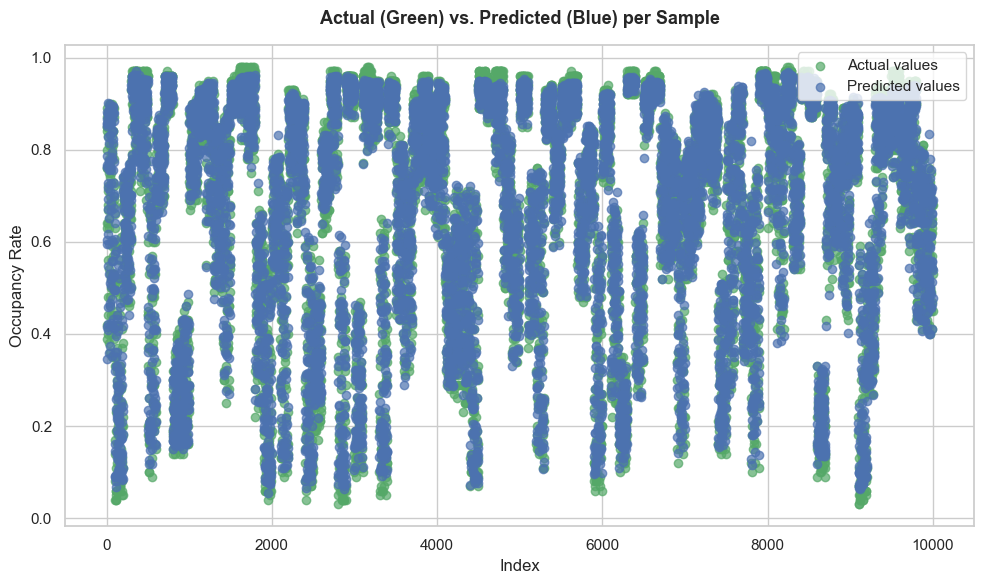

In [56]:
# PLot first 10000 values for better visualization
index_axis = [i for i in range(10000)]
plt.figure(figsize=(10,6))
plt.scatter(y=y_test[:10000],x=index_axis,color='g',marker='o',alpha=0.7,label="Actual values")
plt.scatter(y=y_pred[:10000],x=index_axis,color='b',marker='o', alpha=0.7,label="Predicted values")
plt.ylabel("Occupancy Rate")
plt.xlabel("Index")
plt.title("Actual (Green) vs. Predicted (Blue) per Sample", fontsize=13, fontweight="bold", pad=15)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

### Feature Importance in Model

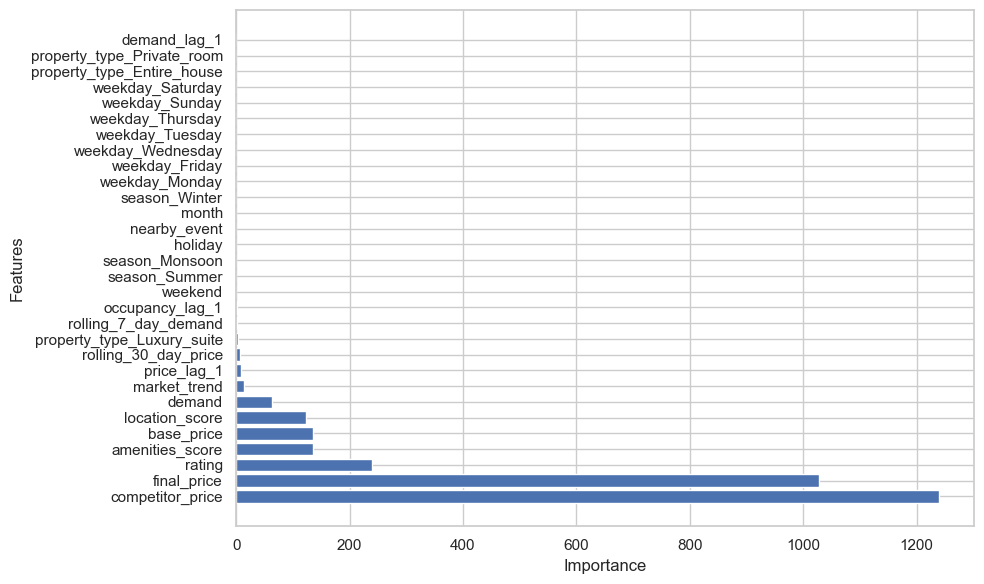

In [57]:
feature_importance_df = pd.DataFrame({
  'features': X_test.columns,
  'importance': model.feature_importances_
})
feature_importance_df = feature_importance_df.sort_values(
  'importance',
  ascending=False
)

plt.figure(figsize=(10,6))
plt.barh(feature_importance_df['features'],feature_importance_df['importance'])
plt.xlabel('Importance')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

### Predict best prices for maximum revenue

In [58]:
def predict_prices_batch(model, test_dataset: pd.DataFrame, max_price_steps=50):
    N = len(test_dataset)  
    M = max_price_steps    
    
    df_expanded = test_dataset.loc[test_dataset.index.repeat(M)].copy()
    
    price_increments = np.tile(np.arange(M) * 5, N)
    df_expanded['final_price'] = df_expanded['base_price'] + price_increments
    
    predicted_occupancies = model.predict(df_expanded)
    
    prices_matrix = df_expanded['final_price'].values.reshape(N, M)
    occupancy_matrix = predicted_occupancies.reshape(N, M)
    
    revenue_matrix = prices_matrix * occupancy_matrix
    
    best_indices = np.argmax(revenue_matrix, axis=1)
    best_prices = prices_matrix[np.arange(N), best_indices]
    
    max_revenues = np.max(revenue_matrix, axis=1)
    
    return best_prices.tolist(), max_revenues.tolist()

### Plot Revenue Increase

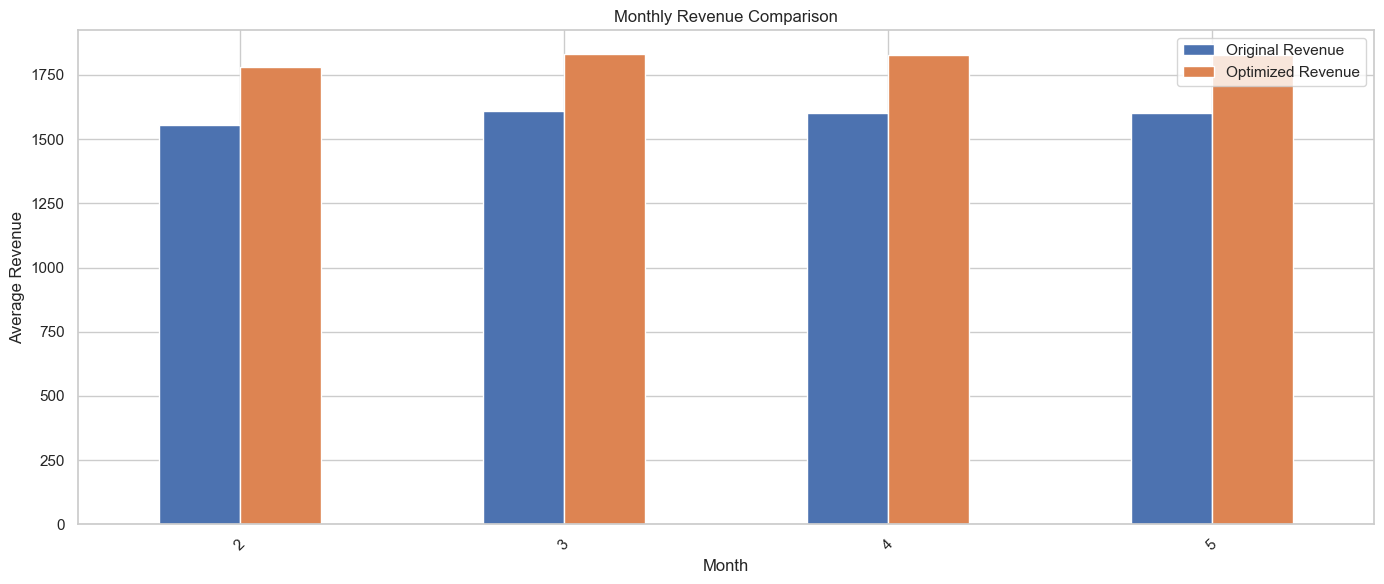

In [62]:
best_prices, max_optim_revenues = predict_prices_batch(model,X_test)
test_dataset['optimized_prices'] = best_prices
test_dataset['optimized_revenue'] = max_optim_revenues

original_revenue_monthly = (
  test_dataset
  .groupby(test_dataset['date'].dt.month)['revenue']
  .mean()
)

optimized_revenue_monthly = (
  test_dataset
  .groupby(test_dataset['date'].dt.month)['optimized_revenue']
  .mean()
)

comparison_df = pd.DataFrame({
    'Original Revenue': original_revenue_monthly,
    'Optimized Revenue': optimized_revenue_monthly
})

comparison_df.plot(
    kind='bar',
    figsize=(14,6)
)

plt.title(
    'Monthly Revenue Comparison'
)

plt.ylabel('Average Revenue')

plt.xlabel('Month')

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [63]:
uplift = (
    (
        comparison_df['Optimized Revenue']
        -
        comparison_df['Original Revenue']
    )
    /
    comparison_df['Original Revenue']
) * 100
print(
    f"Average Revenue Uplift: {uplift.mean():.2f}%"
)

Average Revenue Uplift: 14.20%


### Model produces an revenue uplift of: 14.20% monthly

### Residual Plot

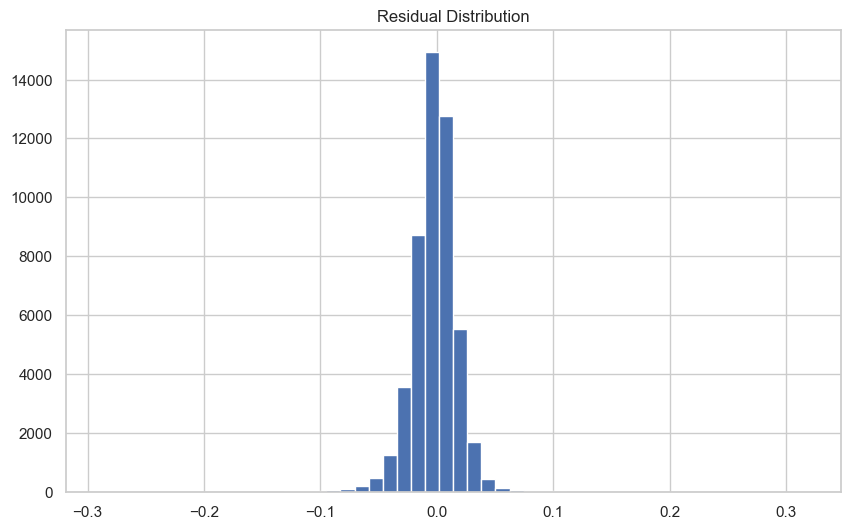

In [64]:
residuals = y_test - y_pred

plt.figure(figsize=(10,6))

plt.hist(residuals, bins=50)

plt.title('Residual Distribution')

plt.show()

### Key Insights:
- Competitor pricing was the strongest predictor of occupancy.
- Rating significantly influences occupancy.
- Dynamic pricing optimization increased average revenue by ~14%.
- The model achieved 0.99 R² on unseen future data.
- Pricing optimization generally lowered prices while improving occupancy.